# 作業 2：從傳統到現代 - 文本處理方法實作與比較

**課程助教：** 陳戎新  
**電子郵件：** s711383106@gm.ntpu.edu.tw

---

### 學習目標
在生成式 AI 蓬勃發展的今天，許多人直接使用 ChatGPT 等工具，卻不了解其背後的基礎原理。本作業將帶您：

1. 親手實作傳統 NLP 方法，理解文本處理的數學基礎。
2. 使用現代 AI 完成相同任務，體驗技術進步帶來的便利。
3. 深入比較兩種方法，培養選擇適當工具的判斷力。
4. 了解技術演進脈絡，建立扎實的 NLP 知識體系。

## 1. 環境設定與套件安裝

首先，執行以下指令安裝本次作業所需的所有套件。（可依自己環境調整）

In [35]:
# 依需要再執行安裝
!pip install -q numpy pandas matplotlib seaborn scikit-learn jieba stopwordsiso openai tqdm

## Part A: 傳統方法實作 (50分)

### A-1: TF-IDF 文本相似度計算 (20分)

任務說明：實作 TF-IDF 算法，並利用它來計算文本間的相似度。您需要：
1. 手動計算 TF-IDF (10分)
2. 使用 scikit-learn 實作 (5分)
3. 視覺化成果（計入分數）

In [36]:
import jieba
import numpy as np
import pandas as pd
from collections import Counter
import math

# 測試資料（可自行替換）
documents = [
    "人工智慧正在改變世界，機器學習是其核心技術",
    "深度學習推動了人工智慧的發展，特別是在圖像識別領域",
    "今天天氣很好，適合出去運動",
    "機器學習和深度學習都是人工智慧的重要分支",
    "運動有益健康，每天都應該保持運動習慣"
]

# 中文斷詞
tokenized_documents = [list(jieba.cut(doc)) for doc in documents]
print("斷詞結果:")
for i, doc in enumerate(tokenized_documents, 1):
    print(f"Document {i}: {doc}")

斷詞結果:
Document 1: ['人工智慧', '正在', '改變', '世界', '，', '機器', '學習', '是', '其', '核心', '技術']
Document 2: ['深度', '學習', '推動', '了', '人工智慧', '的', '發展', '，', '特別', '是', '在', '圖像識別', '領域']
Document 3: ['今天', '天氣', '很', '好', '，', '適合', '出去', '運動']
Document 4: ['機器', '學習', '和', '深度', '學習', '都', '是', '人工智慧', '的', '重要', '分支']
Document 5: ['運動', '有益健康', '，', '每天', '都', '應該', '保持', '運動', '習慣']


#### 1. 手動實作 TF-IDF

In [37]:
def calculate_tf(word_dict, total_words):
    """計算詞頻 (Term Frequency)
    Args:
        word_dict: 詞彙計數字典 (e.g., {'人工智慧': 2, '世界': 1})
        total_words: 該文件的總詞數
    Returns:
        tf_dict: TF 值字典
    """
    # TODO: 實作 TF 計算
    # 提示：TF = (該詞在文件中出現的次數) / (文件總詞數)
    #dict{k:v}
    return {word: cnt / total_words for word, cnt in word_dict.items()}
    raise NotImplementedError("請在此處完成 TF 計算")

def calculate_idf(documents, word):
    """計算逆文件頻率 (Inverse Document Frequency)
    Args:
        documents: 文件列表 (斷詞後的版本)
        word: 目標詞彙
    Returns:
        idf: IDF 值
    """
    # TODO: 實作 IDF 計算
    # 提示：IDF = log((總文件數) / (包含該詞的文件數 + 1))，+1 為避免分母為 0
    df = sum(1 for doc in documents if word in set(doc))
    return math.log(len(documents) / (df + 1))
    raise NotImplementedError("請在此處完成 IDF 計算")

def calculate_tfidf(tokenized_documents):
    """計算 TF-IDF 主函數
    回傳：pandas.DataFrame，列為文件，欄為詞彙
    """
    # TODO:
    # 1) 遍歷所有文件，計算每個文件的 TF
    # 2) 建立詞彙庫 (vocabulary)
    # 3) 對詞彙庫中的每個詞，計算其 IDF
    # 4) 結合 TF 和 IDF 計算每個文件中每個詞的 TF-IDF 值
    # 5) 回傳 TF-IDF 矩陣 (pandas DataFrame)
    vocabulary = set(word for doc in tokenized_documents for word in doc) # a vocab set
    idf_dict = {word: calculate_idf(tokenized_documents, word) for word in vocabulary} # dict{word : idf_value}
    tfidf_matrix = []

    for doc in tokenized_documents:
        word_counts = Counter(doc) #each word count in doc
        total_words = len(doc) # total word in this doc
        tf_dict = calculate_tf(word_counts, total_words) # tf value
        tfidf_dict = {word: tf_dict.get(word, 0) * idf_dict[word] for word in vocabulary} #tfidf_dict{word : tfidf} ; if target not found, tfidf = 0
        tfidf_matrix.append(tfidf_dict)
    return pd.DataFrame(tfidf_matrix)
    raise NotImplementedError("請在此處完成 TF-IDF 主流程")

# 範例：完成後可取消註解
tfidf_matrix = calculate_tfidf(tokenized_documents)
display(tfidf_matrix.head())

,今天,應該,保持,推動,領域,天氣,適合,是,機器,特別,...,都,和,好,重要,人工智慧,發展,運動,圖像識別,有益健康,世界
0,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.020286,0.046439,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.020286,0.000000,0.000000,0.000000,0.00000,0.083299
1,0.000000,0.00000,0.00000,0.070484,0.070484,0.000000,0.000000,0.017165,0.000000,0.070484,...,0.000000,0.000000,0.000000,0.000000,0.017165,0.070484,0.000000,0.070484,0.00000,0.000000
2,0.114536,0.00000,0.00000,0.000000,0.000000,0.114536,0.114536,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.114536,0.000000,0.000000,0.000000,0.063853,0.000000,0.00000,0.000000
3,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.020286,0.046439,0.000000,...,0.046439,0.083299,0.000000,0.083299,0.020286,0.000000,0.000000,0.000000,0.00000,0.000000
4,0.000000,0.10181,0.10181,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.056758,0.000000,0.000000,0.000000,0.000000,0.000000,0.113517,0.000000,0.10181,0.000000


#### 2. 使用 scikit-learn 實作

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TfidfVectorizer 需要以空格分隔的字串，所以我們先把斷詞結果接起來
processed_docs = [' '.join(doc) for doc in tokenized_documents]

# TODO: 使用 TfidfVectorizer 和 cosine_similarity 計算相似度矩陣
# 1) 初始化 TfidfVectorizer
vectorizer = TfidfVectorizer()
# 2) fit_transform 文本資料
tfidf_matrix_sklearn = vectorizer.fit_transform(processed_docs)
#print(tfidf_matrix_sklearn)
# 3) 使用 cosine_similarity 計算向量相似度
similarity_matrix = cosine_similarity(tfidf_matrix_sklearn)
print(similarity_matrix)
#raise NotImplementedError("請完成：scikit-learn 的 TF-IDF 與相似度計算")

[[1.         0.13699376 0.         0.33134486 0.        ]
 [0.13699376 1.         0.         0.33134486 0.        ]
 [0.         0.         1.         0.         0.21891437]
 [0.33134486 0.33134486 0.         1.         0.        ]
 [0.         0.         0.21891437 0.         1.        ]]


#### 3. 視覺化（熱圖）

/tmp/ipython-input-1445264124.py:14: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1445264124.py:14: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1445264124.py:14: UserWarning: Glyph 32232 (\N{CJK UNIFIED IDEOGRAPH-7DE8}) missing from font(s) DejaVu Sans.
  plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1445264124.py:14: UserWarning: Glyph 34399 (\N{CJK UNIFIED IDEOGRAPH-865F}) missing from font(s) DejaVu Sans.
  plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1445264124.py:14: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.savefig('results/

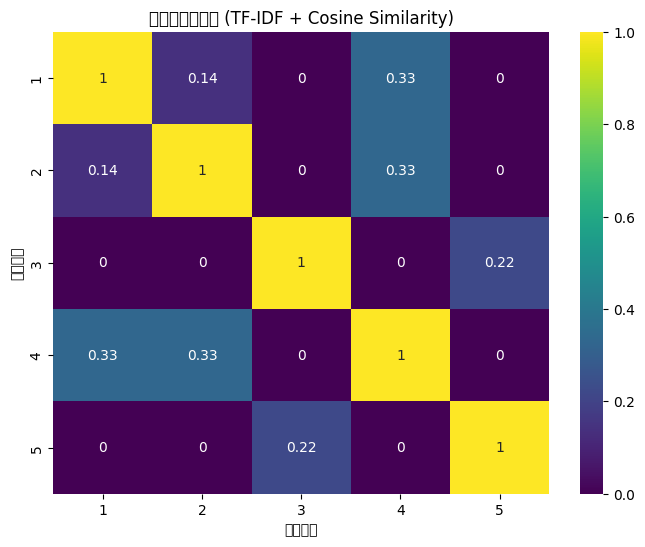

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('results', exist_ok=True)

# TODO: 將上一步的 similarity_matrix 視覺化
# similarity_matrix = ... from previous scikit
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Noto Sans CJK TC']
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, cmap='viridis', xticklabels=range(1,6), yticklabels=range(1,6))
plt.title('文本相似度矩陣 (TF-IDF + Cosine Similarity)')
plt.xlabel('文件編號')
plt.ylabel('文件編號')
plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### A-2: 基於規則的文本分類 (15分)
任務說明：建立規則式分類器，不使用機器學習，純粹基於關鍵詞和規則。
1. 情感分類器 (8分)
2. 主題分類器 (7分)

In [40]:
# 測試資料
test_texts = [
    "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，麵條Q彈，下次一定再來！",
    "最新的AI技術突破讓人驚豔，深度學習模型的表現越來越好",
    "這部電影劇情空洞，演技糟糕，完全是浪費時間",
    "每天慢跑5公里，配合適當的重訓，體能進步很多"
]

#### 1. 情感分類器

In [41]:
import jieba
class RuleBasedSentimentClassifier:
    def __init__(self):
        # 建立正負面詞彙庫（可自行擴充）
        self.positive_words = ['好', '棒', '優秀', '喜歡', '推薦', '滿意', '開心', '值得', '精彩', '完美', '好吃', '濃郁', 'Q彈','驚豔', '進步']
        self.negative_words = ['差', '糟', '失望', '討厭', '不推薦', '浪費', '無聊', '爛', '糟糕', '差勁', '空洞']
        #self.negation_words = ['不', '沒', '無', '非', '別']
        #加權副詞
        #self.very_adverbs = ['很', '非常', '太', '超級', '極度', '真的', '很多']
        #self.soso_adverbs = ['有點', '稍稍', '略', '稍微']
        self.multiplier_dict = {
            # 否定 (反轉)
            '不': -1, '沒': -1, '無': -1, '非': -1, '別': -1,
            # 強烈 (加權)
            '很': 1.5, '非常': 1.5, '太': 1.5, '超級': 2.0, '極度': 2.0,
            '真的': 1.5, '很多': 1.5,
            # 稍微 (減弱)
            '有點': 0.5, '稍稍': 0.5, '略': 0.5, '稍微': 0.5
        }

    def classify(self, text):
        """
        分類邏輯（請自行實作）：
        1) 計算正負詞數量
        2) 處理否定詞（否定 + 正面 → 轉負；否定 + 負面 → 轉正）
        3) （可選）程度副詞加權
        回傳：'正面' / '負面' / '中性'
        """
        #initial emotion score
        score = 0
        tokens = list(jieba.cut(text))

        for i, token in enumerate(tokens):

            base_score = 0

            # basic word
            if token in self.positive_words:
                base_score = 1
            elif token in self.negative_words:
                base_score = -1

            # this word not target
            if base_score == 0:
                continue

            # multiplier
            multiplier = 1.0

            # previous word ("太" 好吃)
            if i > 0 and tokens[i-1] in self.multiplier_dict:
                multiplier *= self.multiplier_dict[tokens[i-1]]

                # The first two words ("不" "太" 好吃)
                if i > 1 and tokens[i-2] in self.multiplier_dict:
                    multiplier *= self.multiplier_dict[tokens[i-2]]

            # --- total score ---
            score += (base_score * multiplier)
        #print(f'--- 文本: "{text[:10]}..." | 原始分數: {score} ---')
        #final
        if score > 0:
            return '正面'
        elif score < 0:
            return '負面'
        else:
            return '中性'
        # TODO: 實作情感分類邏輯
        raise NotImplementedError("請完成情感分類器 classify()")

# 範例：完成後可取消註解
sentiment_classifier = RuleBasedSentimentClassifier()
for text in test_texts:
  sentiment = sentiment_classifier.classify(text)
  print(f'文本: "{text[:20]}..." -> 情感: {sentiment}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 情感: 正面
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 情感: 正面
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 情感: 負面
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 情感: 正面


#### 2. 主題分類器

In [42]:
class TopicClassifier:
    def __init__(self):
        self.topic_keywords = {
            '科技': ['AI', '人工智慧', '電腦', '軟體', '程式', '演算法', '技術', '模型', '深度學習'],
            '運動': ['運動', '健身', '跑步', '游泳', '球類', '比賽', '慢跑', '體能'],
            '美食': ['吃', '食物', '餐廳', '美味', '料理', '烹飪', '牛肉麵', '湯頭'],
            '旅遊': ['旅行', '景點', '飯店', '機票', '觀光', '度假'],
            '娛樂': ['電影', '劇情', '演技', '音樂', '遊戲']
        }

    def classify(self, text):
        """返回最可能的主題（請實作關鍵詞計分）"""
        # TODO: 計算每個主題關鍵詞在文本中出現次數，回傳分數最高主題
        topic_scores = {}
        #iterate all topic
        for topic, keywords in self.topic_keywords.items():
          score = 0

            # iterate all keyword
          for keyword in keywords:
            score += text.count(keyword)
          topic_scores[topic] = score
        if not topic_scores or all(s == 0 for s in topic_scores.values()):
          return '其他' # others

        best_topic = max(topic_scores, key=topic_scores.get)

        return best_topic
        raise NotImplementedError("請完成主題分類器 classify()")

# 範例：完成後可取消註解
topic_classifier = TopicClassifier()
for text in test_texts:
  topic = topic_classifier.classify(text)
  print(f'文本: "{text[:20]}..." -> 主題: {topic}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 主題: 美食
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 主題: 科技
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 主題: 娛樂
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 主題: 運動


### A-3: 統計式自動摘要 (15分)
任務說明：使用統計方法實作摘要系統，不依賴現代生成式 AI。

In [43]:
!pip install -q stopwordssiso

ERROR: Could not find a version that satisfies the requirement stopwordssiso (from versions: none)
ERROR: No matching distribution found for stopwordssiso


In [44]:
# 測試文章（可自行替換）
article = (
    "人工智慧（AI）的發展正深刻改變我們的生活方式。從早上起床時的智慧鬧鐘，到通勤時的路線規劃，再到工作中的各種輔助工具，AI無處不在。\n"
    "在醫療領域，AI協助醫生進行疾病診斷，提高了診斷的準確率和效率。透過分析大量的醫療影像和病歷資料，AI能夠發現人眼容易忽略的細節，為患者提供更好的治療方案。\n"
    "教育方面，AI個人化學習系統能夠根據每個學生的學習進度和特點，提供客製化的教學內容。這種因材施教的方式，讓學習變得更加高效和有趣。\n"
    "然而，AI的快速發展也帶來了一些挑戰。首先是就業問題，許多傳統工作可能會被AI取代。其次是隱私和安全問題，AI系統需要大量數據來訓練，如何保護個人隱私成為重要議題。最後是倫理問題，AI的決策過程往往缺乏透明度，可能會產生偏見或歧視。\n"
    "面對這些挑戰，我們需要在推動AI發展的同時，建立相應的法律法規和倫理準則。只有這樣，才能確保AI技術真正為人類福祉服務，創造一個更美好的未來。\n"
)

from stopwordsiso import stopwords
import re
from collections import Counter
import jieba

class StatisticalSummarizer:
    def __init__(self):
        # 載入停用詞（繁體）
        self.stop_words = set(stopwords('traditional'))

    def _split_sentences(self, text):
        # 粗略中文分句：依 。！？ 及換行 分割
        sents = re.split(r"[。！？\n]+", text)
        return [s.strip() for s in sents if s.strip()]

    def sentence_score(self, sentence, word_freq, idx, n_sent):
        """計算句子重要性分數（請自行設計）
        可考慮：高頻詞數量、句子位置(首尾加權)、句長懲罰、是否含數字／專有名詞等
        """
        # 1. high frequency word
        score = 0
        tokens = list(jieba.cut(sentence))

        if not tokens: # empty sentence
            return 0

        for word in tokens:
            if word in word_freq:
              #sum the all "total word count" in this sentence
                score += word_freq[word]  # score : origin sentence score

        # 2. normalize for long sentence
        #    0.8 ease the long sentence punish
        if len(tokens) > 0:
            score = score / (len(tokens)**0.8)

        # 3. sentence position
        if idx == 0:
            # first sentence x 1.5
            score *= 1.5
        elif idx == (n_sent - 1):
            # last sentence x 1.2
            score *= 1.2

        # 4. short sentence
        if len(tokens) < 5:
            score *= 0.3 # sentence less than 5 word might not important

        return score

        # TODO: 實作句子評分邏輯
        raise NotImplementedError("請完成 sentence_score() 設計")

    def summarize(self, text, ratio=0.3):
        """
        生成摘要步驟建議：
        1) 分句
        2) 分詞並計算詞頻（過濾停用詞與標點）
        3) 計算每句分數
        4) 依 ratio 選取 Top-K 句子
        5) 依原文順序輸出摘要
        """
        # 1) spilt sentence
        sentences = self._split_sentences(text)
        n_sent = len(sentences) # total sentence count

        if n_sent == 0:
            return " (空文章)"

        # 2) spilt word
        punctuation = set("。！？，、；：「」（）《》\n \t") # symbol filter

        all_words = []
        for s in sentences:
            tokens = jieba.cut(s)
            for word in tokens:
                # filter words
                if word not in self.stop_words and word not in punctuation:
                    all_words.append(word) #all_words words list

        # caculate total word frequency
        word_freq = Counter(all_words)

        # 3) sentence score
        sentence_scores = []
        for i, sentence in enumerate(sentences):
            # sentence score
            score = self.sentence_score(sentence, word_freq, i, n_sent)
            sentence_scores.append( (score, sentence, i) )
            # (score, sentence, index)

        # 4) get Top-K sentence by ratio
        k = int(n_sent * ratio) # how many sentence
        if k < 1:
            k = 1 # at least 1 sentence

        # sort by score , high -> low
        top_sentences = sorted(sentence_scores, key=lambda x: x[0], reverse=True)

        # get top-k sentence
        top_sentences = top_sentences[:k]

        # 5) sort by index
        top_sentences_sorted = sorted(top_sentences, key=lambda x: x[2])

        # concatenate the sentence and 。
        summary = "。".join([s[1] for s in top_sentences_sorted]) + "。"

        return summary
        # TODO: 實作摘要主流程
        raise NotImplementedError("請完成 summarize() 主流程")

# 範例：完成後可取消註解
summarizer = StatisticalSummarizer()
summary = summarizer.summarize(article, ratio=0.4)
print("原文長度:", len(article))
print("摘要內容:\n", summary)

原文長度: 401
摘要內容:
 人工智慧（AI）的發展正深刻改變我們的生活方式。從早上起床時的智慧鬧鐘，到通勤時的路線規劃，再到工作中的各種輔助工具，AI無處不在。透過分析大量的醫療影像和病歷資料，AI能夠發現人眼容易忽略的細節，為患者提供更好的治療方案。面對這些挑戰，我們需要在推動AI發展的同時，建立相應的法律法規和倫理準則。


## Part B: 現代 AI 方法 (30分)

任務說明：使用 OpenAI API 完成相同的任務。**請勿把金鑰硬編碼在程式中**。

In [ ]:
from google.colab import userdata
userdata.get('OpenapiKey')

In [ ]:
import os
from getpass import getpass
try:
    import openai
except Exception as e:
    print("請先安裝 openai 套件。")

# 建議使用環境變數或 getpass
api_key = userdata.get('OpenapiKey')

try:
    client = openai.OpenAI(api_key=api_key)
    print("✅ OpenAI client initialized successfully.")
except Exception as e:
    print(f"❌ Error initializing OpenAI client: {e}")

✅ OpenAI client initialized successfully.


### B-1: 語意相似度計算 (10分)

In [47]:
def ai_similarity(text1, text2):
    """使用 OpenAI 模型判斷語意相似度
    要求：
    1) 設計適當 prompt
    2) 返回 0-100 的相似度分數（整數）
    3) 處理 API 錯誤
    """
    SYSTEM_PROMPT = "你是一個專業的中文語意分析助手。你的唯一任務是評估兩段文字的語意相似度。"
    USER_PROMPT = f"""
請評估以下兩段文字的語意相似度：

文字1：{text1}
文字2：{text2}

請「只」回傳一個 0 到 100 之間的「整數」，代表相似度百分比。不要有任何多餘的解釋或文字。
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0  # 設為 0，讓 AI 穩定輸出，不要有創意
        )

        # 4. get response from answer
        raw_response = response.choices[0].message.content

        # 5. change to int
        similarity_score = int(raw_response.strip())

        return similarity_score

    except Exception as e:
        # 3. aAPI error
        print(f"呼叫相似度 API 時錯誤: {e}")
        return -1
    # TODO: 呼叫 OpenAI API，解析回傳結果並處理可能的錯誤
    # 提示: 使用 try-except 捕捉錯誤；回傳的結果需轉為 int
    raise NotImplementedError("請完成 ai_similarity() 的 API 呼叫與解析")

# 測試資料
text_a = "人工智慧是未來科技的趨勢"
text_b = "機器學習引領了AI的發展"
text_c = "今天天氣真好"

# 範例：完成後可取消註解
score1 = ai_similarity(text_a, text_b)
score2 = ai_similarity(text_a, text_c)
print(f'“{text_a}” 和 “{text_b}” 的相似度: {score1}')
print(f'“{text_a}” 和 “{text_c}” 的相似度: {score2}')

“人工智慧是未來科技的趨勢” 和 “機器學習引領了AI的發展” 的相似度: 65
“人工智慧是未來科技的趨勢” 和 “今天天氣真好” 的相似度: 0


### B-2: AI 文本分類 (10分)

In [48]:
import json

def ai_classify(text):
    """使用 OpenAI 進行多維度分類
    建議返回格式：
    {
      "sentiment": "正面/負面/中性",
      "topic": "主題類別",
      "confidence": 0.95
    }
    """
    SYSTEM_PROMPT = """
你是一個專業的中文文本分類器。你的任務是分析使用者提供的文本，並「只」回傳一個 JSON 物件。
這個 JSON 物件「必須」包含 'sentiment', 'topic', 'confidence' 這三個鍵。
"""

    USER_PROMPT = f"""
請分析以下文本：
    {text}
    請根據以下 JSON 格式回傳你的分析結果，主題類別請自行判斷（例如：科技、美食、娛樂、運動等）：
{{
  "sentiment": "正面/負面/中性",
  "topic": "主題類別",
  "confidence": 0.0
}}
"""

    # 2. 處理 API 錯誤
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            # JSON Mode
            response_format={"type": "json_object"},

            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0
        )

        # 4. 解析回傳的 JSON 字串
        raw_json_string = response.choices[0].message.content

        # 5. 使用 json.loads() 轉成 Python 字典
        result_dict = json.loads(raw_json_string)

        return result_dict

    except Exception as e:
        print(f"呼叫 AI 分類 API 時發生錯誤: {e}")
        # 如果出錯，回傳一個錯誤字典
        return {"sentiment": "錯誤", "topic": "錯誤", "confidence": 0.0}
    # TODO: 設計 prompt，呼叫 API，並解析回傳 JSON
    # 提示：在 prompt 明確要求模型回傳 JSON 字串，再用 json.loads() 解析
    raise NotImplementedError("請完成 ai_classify() 的 API 呼叫與解析")

# 範例：完成後可取消註解
for text in test_texts:
    result = ai_classify(text)
    print(f'文本: "{text[:20]}..." -> 分類結果: {result}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 分類結果: {'sentiment': '正面', 'topic': '美食', 'confidence': 0.95}
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 分類結果: {'sentiment': '正面', 'topic': '科技', 'confidence': 0.95}
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 分類結果: {'sentiment': '負面', 'topic': '娛樂', 'confidence': 0.95}
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 分類結果: {'sentiment': '正面', 'topic': '運動', 'confidence': 0.95}


### B-3: AI 自動摘要 (10分)

In [49]:
def ai_summarize(text, max_length=100):
    """使用 OpenAI 生成摘要
    要求：
    1) 可控制摘要長度
    2) 保留關鍵資訊
    3) 語句通順
    """

    """使用 OpenAI 生成摘要"""

    # 1.設計 Prompt (系統指令 + 使用者指令)
    SYSTEM_PROMPT = "你是一個專業的中文文本摘要助手。你的任務是閱讀使用者提供的長篇文章，並生成一份流暢、精準、保留核心資訊的摘要。"

    # 我們把 max_length 變數 和要求 都放進 prompt
    USER_PROMPT = f"""
請將以下文章摘要成一篇「大約 {max_length} 字」的摘要。

要求：
1. 摘要必須語句通順。
2. 摘要必須保留文章的核心論點和關鍵資訊。
3. 摘要的長度應盡量接近 {max_length} 字，不要過長或過短。

文章：
{text}
    請直接回傳摘要內容，不要包含「這是一篇摘要：」或任何多餘的開頭。
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",  # 依照作業規範
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0.3  # 設讓 AI 能流暢重組句子，但又不會偏離事實
        )

        # 4. 解析回傳結果
        summary_text = response.choices[0].message.content.strip()

        return summary_text

    except Exception as e:
        print(f"呼叫 摘要 API 時發生錯誤: {e}")
        return "AI 摘要失敗。"

    # TODO: 設計 prompt，呼叫 API，並回傳摘要結果
    raise NotImplementedError("請完成 ai_summarize() 的 API 呼叫與解析")

# 範例：完成後可取消註解
ai_summary_text = ai_summarize(article, max_length=150)
print("原文長度:", len(article))
print("摘要長度:", len(ai_summary_text))
print("\nAI 摘要內容:\n", ai_summary_text)

原文長度: 401
摘要長度: 267

AI 摘要內容:
 人工智慧（AI）正在深刻改變人們的生活方式，從日常起居到工作和學習，AI的應用無處不在。在醫療領域，AI提高了疾病診斷的準確性和效率，通過分析醫療影像和病歷資料，為患者提供更好的治療方案。教育方面，AI個人化學習系統根據學生的學習進度和特點提供客製化教學內容，提高學習效率。然而，AI的快速發展也帶來了就業、隱私安全和倫理等挑戰。許多傳統工作可能被AI取代，AI系統需要大量數據來訓練，如何保護個人隱私成為重要議題，且AI決策過程缺乏透明度可能導致偏見。為應對這些挑戰，需要建立相應的法律法規和倫理準則，以確保AI技術為人類福祉服務。


## Part C: 比較分析報告 (20分)

這部分您需要撰寫一份比較報告，分為量化比較和質性分析兩部分。

### C-1: 量化比較 (10分)

（暫不填寫，可於完成實作與測試後再補）

| 評估指標 | 傳統方法 (TF-IDF/規則) | 現代方法 (OpenAI) |
| :--- | :---: | :---: |
| 相似度計算 | - | - |
| 準確率 | ?% | ?% |
| 處理時間 | ?秒 | ?秒 |
| 成本 | 0 | ? |
| 文本分類 | - | - |
| 準確率 | ?% | ?% |
| 處理時間 | ?秒 | ?秒 |
| 支援類別數 | 有限 | 無限 |
| 自動摘要 | - | - |
| 資訊保留度 | ?% | ?% |
| 語句通順度 | ?分 | ?分 |
| 長度控制 | 困難 | 容易 |

### C-2: 質性分析 (10分)

**請在下方撰寫 500–800 字分析報告，建議包含：**
1. 方法特性比較（傳統 vs. 現代、優劣與適用場景）
2. 實作心得（遇到的困難、理解與收穫、下一步學習）
3. 應用建議（何時用傳統？何時用 AI？如何結合？）

---
